# WoE and IV walkthrough for the presentation

This notebook prepares supporting material for the business presentation: a
step-by-step look at how Weight of Evidence (WoE) and Information Value (IV)
were used to study candidate variables before they entered the final
17-variable scorecard (full development in 04_scorecard_woe.ipynb).

Four variables are walked through here, chosen to be intuitive for a
non-technical audience while representative of the different types of
variable in the final model: numeric and categorical, personal profile and
external bureau history.

In [1]:
# Import core libraries and load the train_bureau artifact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_bureau = pd.read_csv('../data/processed/train_bureau.csv')
print(train_bureau.shape)

(307511, 156)


In [29]:
train_bureau.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT,BUREAU_CREDIT_ACTIVE_BAD_DEBT_COUNT,BUREAU_CREDIT_ACTIVE_CLOSED_COUNT,BUREAU_CREDIT_ACTIVE_SOLD_COUNT,BUREAU_CREDIT_TYPE_MODE_COUNT,NAME_EDUCATION_TYPE_BINNED
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-499.875,-7.0,0.0,0.0,2.0,0.0,6.0,0.0,4.0,Secondary / secondary special
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-816.000,-43.0,0.0,NaN,1.0,0.0,3.0,0.0,2.0,Higher education


In [30]:
train_bureau['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

## Quick recap: WoE and IV

Weight of Evidence (WoE) measures how much a bin (a value range or category)
associates with lower or higher risk, relative to the overall client base.
Positive WoE means the bin is safer than average; negative WoE means it is
riskier. Information Value (IV) summarizes a variable's overall
discriminative power by combining the WoE of every bin.

Before any variable entered the final scorecard, its bins were checked for
monotonicity: does risk change consistently in one direction as the
variable increases, or as categories move from lower to higher risk? A
monotonic pattern is what makes a scorecard variable easy to explain to a
business audience.

In [8]:
# Define reusable WoE/IV function for numeric variables (quantile binning + explicit Missing bin, with smoothing)
def calculate_woe_iv(df, feature_col, target_col='TARGET', n_bins=10, smoothing=0.5, min_bad_per_bin=100):
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
    woe_df['bin'] = pd.qcut(woe_df[feature_col], q=n_bins, duplicates='drop').astype('object')
    woe_df.loc[woe_df[feature_col].isnull(), 'bin'] = 'Missing'

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    unstable = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable) > 0:
        print(f"NOTE [{feature_col}]: {len(unstable)} bin(s) with fewer than {min_bad_per_bin} bad cases")

    return grouped[['bin', 'n_total', 'n_bad', 'woe', 'iv_component']], iv_total

In [6]:
# Define reusable WoE/IV function for categorical variables (one bin per category, with smoothing)
def calculate_woe_iv_categorical(df, feature_col, target_col='TARGET', smoothing=0.5, min_bad_per_bin=100):
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
    woe_df[feature_col] = woe_df[feature_col].astype('object').fillna('Missing')

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby(feature_col, observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index().rename(columns={feature_col: 'bin'})
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    unstable = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable) > 0:
        print(f"NOTE [{feature_col}]: {len(unstable)} categor(y/ies) with fewer than {min_bad_per_bin} bad cases")

    return grouped.sort_values('woe')[['bin', 'n_total', 'n_bad', 'woe', 'iv_component']], iv_total

## Example 1: Years employed (numeric, personal profile)

Business hypothesis: the longer a client has been in their current job, the
more stable their income, and the lower the risk.

In [9]:
# Calculate WoE/IV for YEARS_EMPLOYED
years_employed_woe, years_employed_iv = calculate_woe_iv(train_bureau, 'YEARS_EMPLOYED')
print(years_employed_woe.round(4).to_string(index=False))
print(f"\nIV total: {years_employed_iv:.4f}")

          bin  n_total  n_bad     woe  iv_component
(-0.001, 0.9]    26366   2919 -0.3489        0.0121
   (0.9, 1.7]    25807   2934 -0.3788        0.0141
   (1.7, 2.5]    24505   2724 -0.3535        0.0116
   (2.5, 3.4]    24845   2543 -0.2611        0.0061
   (3.4, 4.5]    25387   2445 -0.1935        0.0034
   (4.5, 5.9]    24855   2109 -0.0543        0.0002
   (5.9, 7.6]    24751   1841  0.0887        0.0006
  (7.6, 10.1]    25855   1749  0.1909        0.0028
 (10.1, 14.6]    24804   1435  0.3576        0.0089
 (14.6, 49.1]    24962   1136  0.6106        0.0235
      Missing    55374   2990  0.4309        0.0280

IV total: 0.1113


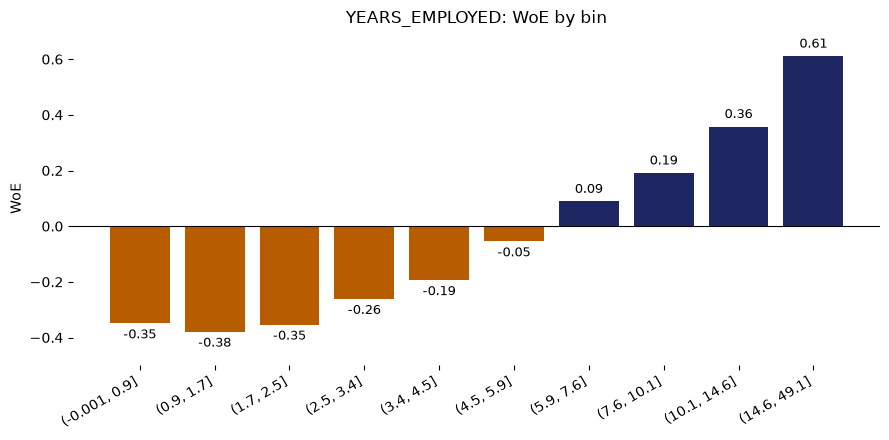

In [12]:
# Plot WoE by bin for YEARS_EMPLOYED
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = years_employed_woe[years_employed_woe['bin'] != 'Missing']

NAVY = '#1E2761'
DARK_ORANGE = '#B85C00'

colors = [NAVY if w >= 0 else DARK_ORANGE for w in plot_data['woe']]
bars = ax.bar(plot_data['bin'].astype(str), plot_data['woe'], color=colors)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('WoE')
ax.set_title('YEARS_EMPLOYED: WoE by bin')
ax.set_ylim(-0.5, 0.7)
plt.xticks(rotation=30, ha='right')

# Remove all chart border lines (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add value labels above/below each bar, depending on sign
for bar, value in zip(bars, plot_data['woe']):
    offset = 0.02 if value >= 0 else -0.02
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.2f}',
             ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

## Example 2: Education level (categorical, personal profile)

Business hypothesis: clients with higher education tend to have more
stable income and job security, associating with lower risk.

In [14]:
# Calculate WoE/IV for NAME_EDUCATION_TYPE_BINNED
education_woe, education_iv = calculate_woe_iv_categorical(train_bureau, 'NAME_EDUCATION_TYPE')
print(education_woe.round(4).to_string(index=False))
print(f"\nIV total: {education_iv:.4f}")

NOTE [NAME_EDUCATION_TYPE]: 1 categor(y/ies) with fewer than 100 bad cases
                          bin  n_total  n_bad     woe  iv_component
              Lower secondary     3816    417 -0.3353        0.0016
Secondary / secondary special   218391  19524 -0.1114        0.0092
            Incomplete higher    10277    872 -0.0547        0.0001
             Higher education    74863   4009  0.4396        0.0392
              Academic degree      164      3  1.3993        0.0006

IV total: 0.0507


In [15]:
# Merge 'Academic degree' (only 164 clients, unstable WoE) into 'Higher education',
# the closest category in both WoE and business meaning (both represent
# post-secondary education).

train_bureau['NAME_EDUCATION_TYPE_BINNED'] = train_bureau['NAME_EDUCATION_TYPE'].replace(
    {'Academic degree': 'Higher education'}
)

C:\Users\vitor\AppData\Local\Temp\ipykernel_50860\2858104008.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_bureau['NAME_EDUCATION_TYPE_BINNED'] = train_bureau['NAME_EDUCATION_TYPE'].replace(


In [17]:
# Calculate WoE/IV for NAME_EDUCATION_TYPE_BINNED
education_woe, education_iv = calculate_woe_iv_categorical(train_bureau, 'NAME_EDUCATION_TYPE_BINNED')
print(education_woe.round(4).to_string(index=False))
print(f"\nIV total: {education_iv:.4f}")

                          bin  n_total  n_bad     woe  iv_component
              Lower secondary     3816    417 -0.3353        0.0016
Secondary / secondary special   218391  19524 -0.1114        0.0092
            Incomplete higher    10277    872 -0.0547        0.0001
             Higher education    75027   4012  0.4411        0.0395

IV total: 0.0505


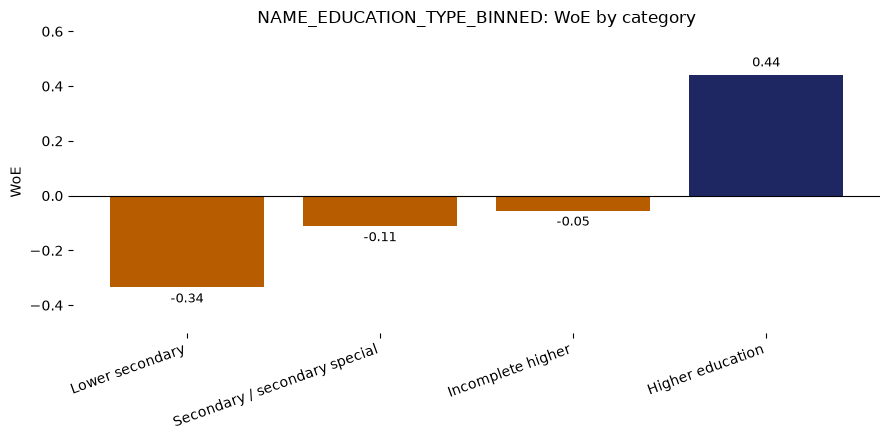

In [18]:
# Plot WoE by category for NAME_EDUCATION_TYPE_BINNED, in natural education order
natural_order = ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher', 'Higher education']
plot_data = education_woe.set_index('bin').loc[natural_order].reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))

NAVY = '#1E2761'
DARK_ORANGE = '#B85C00'

colors = [NAVY if w >= 0 else DARK_ORANGE for w in plot_data['woe']]
bars = ax.bar(plot_data['bin'].astype(str), plot_data['woe'], color=colors)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('WoE')
ax.set_title('NAME_EDUCATION_TYPE_BINNED: WoE by category')
ax.set_ylim(-0.5, 0.6)
plt.xticks(rotation=20, ha='right')

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, plot_data['woe']):
    offset = 0.02 if value >= 0 else -0.02
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.2f}',
             ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

## Example 3: Active credits at other institutions (numeric, external bureau history)

Business hypothesis: the more credits a client has open at the same time in
other institutions, the more financial commitments they are juggling
simultaneously, associating with higher risk.

In [19]:
# Calculate WoE/IV for BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT
active_count_woe, active_count_iv = calculate_woe_iv(train_bureau, 'BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT')
print(active_count_woe.round(4).to_string(index=False))
print(f"\nIV total: {active_count_iv:.4f}")

          bin  n_total  n_bad     woe  iv_component
(-0.001, 1.0]   120444   7881  0.2266        0.0183
   (1.0, 2.0]    58383   4346  0.0879        0.0014
   (2.0, 3.0]    38011   3140 -0.0251        0.0001
   (3.0, 4.0]    22041   2035 -0.1471        0.0016
  (4.0, 32.0]    24612   2966 -0.4449        0.0191
      Missing    44020   4457 -0.2491        0.0099

IV total: 0.0504


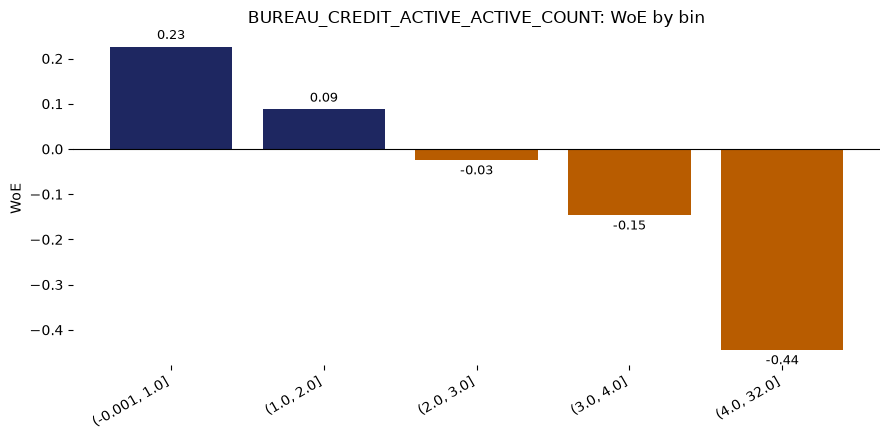

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = active_count_woe[active_count_woe['bin'] != 'Missing']

NAVY = '#1E2761'
DARK_ORANGE = '#B85C00'

colors = [NAVY if w >= 0 else DARK_ORANGE for w in plot_data['woe']]
bars = ax.bar(plot_data['bin'].astype(str), plot_data['woe'], color=colors)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('WoE')
ax.set_title('BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT: WoE by bin')
plt.xticks(rotation=30, ha='right')

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, plot_data['woe']):
    offset = 0.01 if value >= 0 else -0.01
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.2f}',
             ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

## Example 4: Gender (categorical, personal profile)

Included as the simplest example in this walkthrough, and to illustrate a
methodological rigor point: how a very small residual category was handled
without forcing an unfounded correction.

In [21]:
# Calculate WoE/IV for CODE_GENDER
gender_woe, gender_iv = calculate_woe_iv_categorical(train_bureau, 'CODE_GENDER')
print(gender_woe.round(4).to_string(index=False))
print(f"\nIV total: {gender_iv:.4f}")

NOTE [CODE_GENDER]: 1 categor(y/ies) with fewer than 100 bad cases
bin  n_total  n_bad     woe  iv_component
  M   105059  10655 -0.2509        0.0239
XNA        4      0 -0.2352        0.0000
  F   202448  14170  0.1543        0.0147

IV total: 0.0386


## Example 4: External credit score (numeric, the strongest predictor)

EXT_SOURCE_3 is a normalized score sourced from an external credit bureau,
already a risk assessment built by another institution using its own
payment history data. Business hypothesis: a higher external score should
consistently associate with lower risk. This is also the single strongest
predictor in the entire dataset, worth a closer check before accepting it
into the final model.

In [22]:
# Calculate WoE/IV for EXT_SOURCE_3
ext3_woe, ext3_iv = calculate_woe_iv(train_bureau, 'EXT_SOURCE_3')
print(ext3_woe.round(4).to_string(index=False))
print(f"\nIV total: {ext3_iv:.4f}")

               bin  n_total  n_bad     woe  iv_component
(-0.000473, 0.228]    24701   4941 -1.0463        0.1351
     (0.228, 0.33]    24744   3156 -0.5096        0.0259
     (0.33, 0.408]    25057   2383 -0.1796        0.0028
    (0.408, 0.476]    24689   1970  0.0127        0.0000
    (0.476, 0.535]    24186   1494  0.2880        0.0058
    (0.535, 0.592]    25392   1357  0.4416        0.0134
    (0.592, 0.643]    24725   1173  0.5670        0.0204
    (0.643, 0.694]    24745   1043  0.6907        0.0289
    (0.694, 0.749]    23675    836  0.8747        0.0412
    (0.749, 0.896]    24632    795  0.9678        0.0506
           Missing    60965   5677 -0.1562        0.0052

IV total: 0.3293


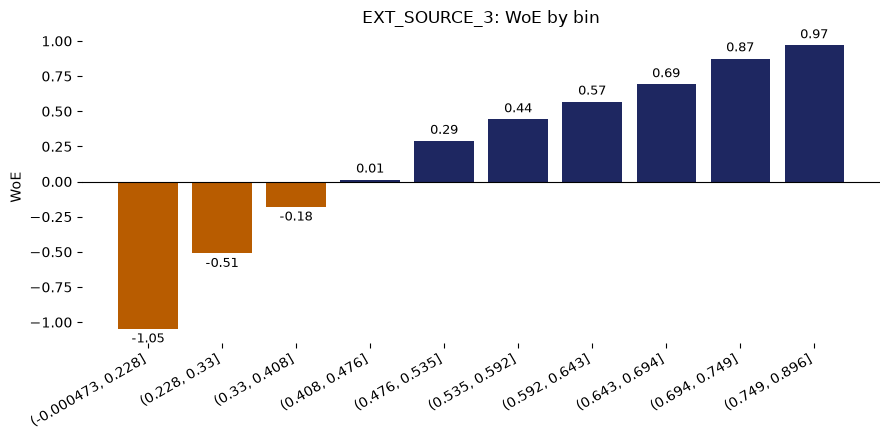

In [23]:
# Plot WoE by bin for EXT_SOURCE_3
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = ext3_woe[ext3_woe['bin'] != 'Missing']

NAVY = '#1E2761'
DARK_ORANGE = '#B85C00'

colors = [NAVY if w >= 0 else DARK_ORANGE for w in plot_data['woe']]
bars = ax.bar(plot_data['bin'].astype(str), plot_data['woe'], color=colors)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('WoE')
ax.set_title('EXT_SOURCE_3: WoE by bin')
plt.xticks(rotation=30, ha='right')

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, plot_data['woe']):
    offset = 0.03 if value >= 0 else -0.03
    va = 'bottom' if value >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.2f}',
             ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

## Scorecard business gain curve

Two complementary views of the same result: absolute reduction in default
rate (percentage points) and relative reduction (how much lower the default
rate is, compared to the current 8.07% baseline).

In [24]:
# Build the scorecard gain curve dataframe, including the relative reduction (%)
gain_summary_scorecard = pd.DataFrame({
    'pct_rejeitado': [0, 5, 10, 15, 20, 25, 30],
    'clientes_aprovados': [61503, 58428, 55353, 52278, 49203, 46128, 43053],
    'pct_aprovado': [100, 95, 90, 85, 80, 75, 70],
    'inadimplencia_aprovados_pct': [8.07, 6.88, 6.12, 5.63, 5.14, 4.69, 4.31],
    'reducao_pp': [0.00, 1.19, 1.95, 2.45, 2.93, 3.38, 3.76],
})

baseline = gain_summary_scorecard['inadimplencia_aprovados_pct'].iloc[0]
gain_summary_scorecard['reducao_relativa_pct'] = (gain_summary_scorecard['reducao_pp'] / baseline * 100).round(1)

print(gain_summary_scorecard.to_string(index=False))

 pct_rejeitado  clientes_aprovados  pct_aprovado  inadimplencia_aprovados_pct  reducao_pp  reducao_relativa_pct
             0               61503           100                         8.07        0.00                   0.0
             5               58428            95                         6.88        1.19                  14.7
            10               55353            90                         6.12        1.95                  24.2
            15               52278            85                         5.63        2.45                  30.4
            20               49203            80                         5.14        2.93                  36.3
            25               46128            75                         4.69        3.38                  41.9
            30               43053            70                         4.31        3.76                  46.6


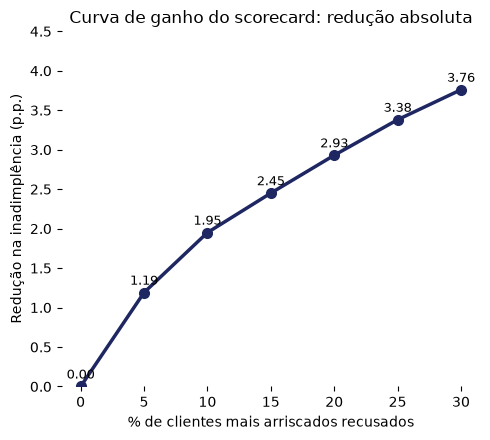

In [26]:
# Plot gain curve: absolute reduction in default rate (percentage points)
fig, ax = plt.subplots(figsize=(5, 4.5))

NAVY = '#1E2761'

ax.plot(gain_summary_scorecard['pct_rejeitado'], gain_summary_scorecard['reducao_pp'],
        marker='o', color=NAVY, linewidth=2.5, markersize=7)

for x, y in zip(gain_summary_scorecard['pct_rejeitado'], gain_summary_scorecard['reducao_pp']):
    ax.text(x, y + 0.1, f'{y:.2f}', ha='center', fontsize=9)

ax.set_xlabel('% de clientes mais arriscados recusados')
ax.set_ylabel('Redução na inadimplência (p.p.)')
ax.set_title('Curva de ganho do scorecard: redução absoluta')
ax.set_ylim(0, 4.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

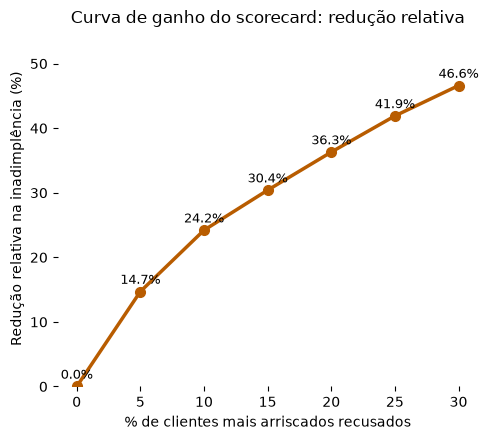

In [28]:
# Plot gain curve: relative reduction in default rate (%)
fig, ax = plt.subplots(figsize=(5, 4.5))

DARK_ORANGE = '#B85C00'

ax.plot(gain_summary_scorecard['pct_rejeitado'], gain_summary_scorecard['reducao_relativa_pct'],
        marker='o', color=DARK_ORANGE, linewidth=2.5, markersize=7)

for x, y in zip(gain_summary_scorecard['pct_rejeitado'], gain_summary_scorecard['reducao_relativa_pct']):
    ax.text(x, y + 1.2, f'{y:.1f}%', ha='center', fontsize=9)

ax.set_xlabel('% de clientes mais arriscados recusados')
ax.set_ylabel('Redução relativa na inadimplência (%)')
ax.set_title('Curva de ganho do scorecard: redução relativa')
ax.set_ylim(0, 55)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()